# Disease Outbreak Early Warning System

## Notebook 02: Exploratory Time Series Analysis

### Purpose

This notebook explores historical dengue incidence patterns and environmental characteristics to identify trends, seasonality, variability, and potential outbreak signals.

### Objectives

* Explore dengue case distributions
* Compare disease incidence across cities
* Visualize temporal disease trends
* Investigate seasonality
* Generate figures for future forecasting analysis

### Expected Outcome

A comprehensive understanding of the structure and behavior of dengue incidence data before model development.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)

os.makedirs("images", exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Loading the Integrated Dataset

The merged dengue surveillance dataset from Notebook 01 is loaded for exploratory analysis.


In [2]:
features = pd.read_csv(
    "/content/dengue_features_train.csv"
)

labels = pd.read_csv(
    "/content/dengue_labels_train.csv"
)

dengue_df = pd.merge(
    features,
    labels,
    on=[
        "city",
        "year",
        "weekofyear"
    ]
)

dengue_df.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6


## Summary Statistics

Descriptive statistics provide a preliminary understanding of dengue case distributions and environmental conditions.


In [3]:
dengue_df.describe()

,year,weekofyear,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
count,1456.000000,1456.000000,1262.000000,1404.000000,1434.000000,1434.000000,1443.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1443.000000,1446.000000,1446.000000,1413.000000,1413.000000,1436.000000,1442.000000,1434.000000,1456.000000
mean,2001.031593,26.503434,0.142294,0.130553,0.203783,0.202305,45.760388,298.701852,299.225578,295.246356,303.427109,295.719156,40.151819,82.161959,45.760388,16.746427,4.903754,27.185783,8.059328,32.452437,22.102150,39.326360,24.675137
std,5.408314,15.019437,0.140531,0.119999,0.073860,0.083903,43.715537,1.362420,1.261715,1.527810,3.234601,2.565364,43.434399,7.153897,43.715537,1.542494,3.546445,1.292347,2.128568,1.959318,1.574066,47.455314,43.596000
min,1990.000000,1.000000,-0.406250,-0.456100,-0.015533,-0.063457,0.000000,294.635714,294.892857,289.642857,297.800000,286.900000,0.000000,57.787143,0.000000,11.715714,1.357143,21.400000,4.528571,26.700000,14.700000,0.000000,0.000000
25%,1997.000000,13.750000,0.044950,0.049217,0.155087,0.144209,9.800000,297.658929,298.257143,294.118929,301.000000,293.900000,13.055000,77.177143,9.800000,15.557143,2.328571,26.300000,6.514286,31.100000,21.100000,8.700000,5.000000
50%,2002.000000,26.500000,0.128817,0.121429,0.196050,0.189450,38.340000,298.646429,299.289286,295.640714,302.400000,296.200000,27.245000,80.301429,38.340000,17.087143,2.857143,27.414286,7.300000,32.800000,22.200000,23.850000,12.000000
75%,2005.000000,39.250000,0.248483,0.216600,0.248846,0.246982,70.235000,299.833571,300.207143,296.460000,305.500000,297.900000,52.200000,86.357857,70.235000,17.978214,7.625000,28.157143,9.566667,33.900000,23.300000,53.900000,28.000000
max,2010.000000,53.000000,0.508357,0.454429,0.538314,0.546017,390.600000,302.200000,302.928571,298.450000,314.000000,299.900000,570.500000,98.610000,390.600000,20.461429,16.028571,30.800000,15.800000,42.200000,25.600000,543.300000,461.000000


## Distribution of Dengue Cases

Understanding the distribution of disease incidence helps identify skewness, variability, and potential outbreak periods.


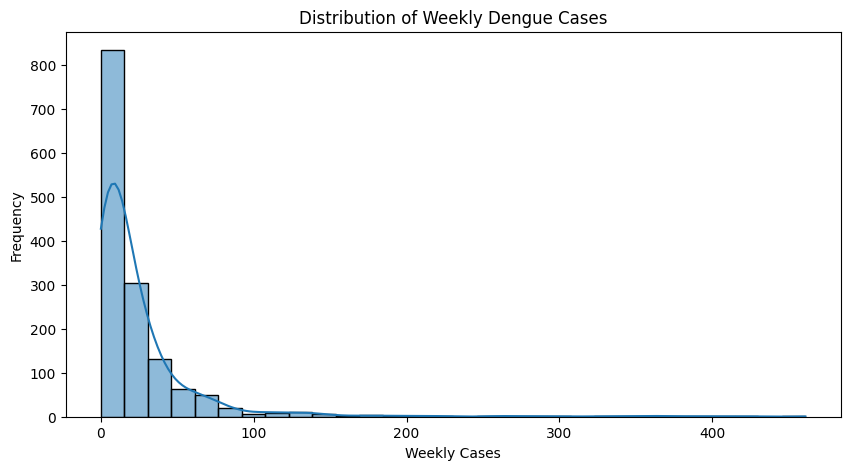

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    dengue_df["total_cases"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Weekly Dengue Cases"
)

plt.xlabel("Weekly Cases")
plt.ylabel("Frequency")

plt.savefig(
    "images/dengue_case_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Dengue Cases by City

Disease transmission patterns may differ across geographic locations due to environmental and demographic factors.


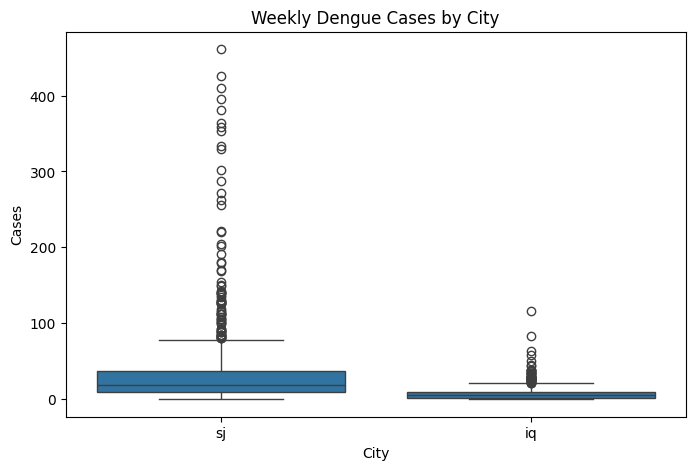

In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=dengue_df,
    x="city",
    y="total_cases"
)

plt.title(
    "Weekly Dengue Cases by City"
)

plt.xlabel("City")
plt.ylabel("Cases")

plt.savefig(
    "images/city_comparison.png",
    bbox_inches="tight"
)

plt.show()

## Annual Dengue Trends

Aggregating disease incidence by year provides insight into long-term outbreak behavior.


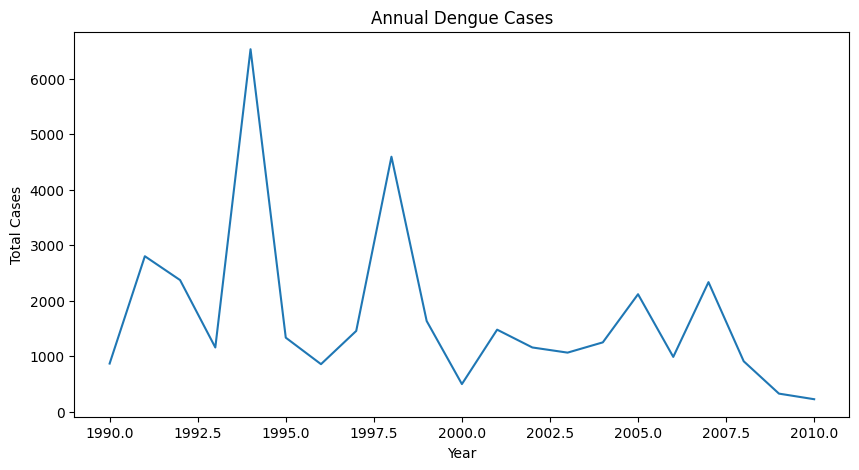

In [6]:
annual_cases = (
    dengue_df
    .groupby("year")["total_cases"]
    .sum()
)

plt.figure(figsize=(10,5))

annual_cases.plot()

plt.title(
    "Annual Dengue Cases"
)

plt.xlabel("Year")
plt.ylabel("Total Cases")

plt.savefig(
    "images/annual_dengue_trend.png",
    bbox_inches="tight"
)

plt.show()

## Weekly Disease Activity

Weekly incidence patterns provide an initial view of seasonality and outbreak fluctuations.


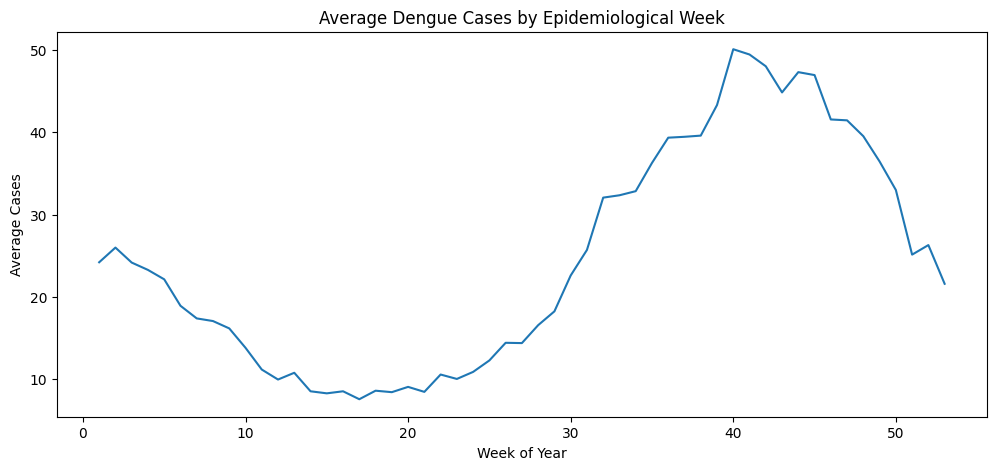

In [7]:
weekly_cases = (
    dengue_df
    .groupby("weekofyear")["total_cases"]
    .mean()
)

plt.figure(figsize=(12,5))

weekly_cases.plot()

plt.title(
    "Average Dengue Cases by Epidemiological Week"
)

plt.xlabel("Week of Year")
plt.ylabel("Average Cases")

plt.savefig(
    "images/seasonality_pattern.png",
    bbox_inches="tight"
)

plt.show()

## Initial Findings

The exploratory analysis provides evidence regarding disease variability, geographic differences, and seasonal outbreak patterns.

These observations will guide the forecasting and outbreak detection models developed in subsequent notebooks.


In [8]:
import os

print(
    os.listdir("images")
)

['annual_dengue_trend.png', 'seasonality_pattern.png', 'dengue_case_distribution.png', 'city_comparison.png']
